In [1]:
import torch
import torchphysics as tp
import pandas as pd
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torch.utils.data import DataLoader
import pytorch_lightning as pl
import os
from pytorch_lightning import loggers as pl_loggers



/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Define dimensions

In [2]:
#Input
X = tp.spaces.R1('x')
Y = tp.spaces.R1('y')
C = tp.spaces.R1("c") # number of case
#output
U = tp.spaces.R1('u')
V = tp.spaces.R1('v')
URMS = tp.spaces.R1('urms')
VRMS = tp.spaces.R1('vrms')
UV=tp.spaces.R1('uv')
P=tp.spaces.R1('p')

# PIAN parameters

In [3]:
# GAN macros
GPU="cuda:0"
GAN_weight=1 # Generator weight
L_x=3.6 # length of domain
N_x=144 # grid in x
N_x_sub=72
N_y=91 # grid in y
N_dists=10 # N 1d roughness for fake images during training

In [4]:
X_interval = tp.domains.Interval(X, 0, L_x) # <-add the bounds of the Interval (0, 2)
Y_interval = tp.domains.Interval(Y, 0, 2.0)
C_interval = tp.domains.Interval(C,0,288) # number of available roughness profiles

Sim_domain = X_interval*Y_interval*C_interval


Y_interval_sub_low=tp.domains.Interval(Y, 0, 0.15)
Sim_domain_sub_low=X_interval*Y_interval_sub_low*C_interval
Y_interval_sub_up=tp.domains.Interval(Y, 2-0.15, 2)
Sim_domain_sub_up=X_interval*Y_interval_sub_up*C_interval



### Read DNS data for discriminator

In [5]:
DF_Data=pd.read_csv("Data/Flow_3d_2289_6_C5X144Y91.csv")

In [6]:
DF=DF_Data[["U","V","urms","vrms","uv",]]

In [7]:
N_c=len(DF_Data["c"].unique()) # number of available training data

In [8]:
DF

,U,V,urms,vrms,uv
0,2.600656e-15,-3.692872e-18,2.140123e-13,8.047987e-16,-1.577949e-29
1,-1.244447e-05,-1.593268e-08,1.448204e-02,1.794938e-04,-8.843710e-07
2,4.322685e-06,2.873018e-06,3.735474e-02,2.134866e-03,-2.881185e-05
3,6.267886e-06,8.694975e-06,4.808667e-02,7.319462e-03,-1.307674e-04
4,1.252351e-05,2.179063e-05,5.116432e-02,1.570136e-02,-3.013878e-04
...,...,...,...,...,...
3773947,-8.718233e-05,1.184230e-05,4.687371e-02,1.523083e-02,1.715897e-05
3773948,-6.205211e-05,1.110968e-05,4.459196e-02,7.541581e-03,1.730195e-05
3773949,-4.603499e-05,4.011976e-06,3.694727e-02,2.517208e-03,4.698951e-06
3773950,-1.669597e-05,1.356909e-06,1.769236e-02,3.101213e-04,1.737829e-07


In [9]:
N_c*144*91

3773952

In [10]:
(2/15)**2/((1-0.1)**3)

0.02438652644413961

In [11]:
DF_Data[["U","V","urms","vrms","uv"]].to_numpy().transpose((1,0)).reshape((5,-1))

array([[ 2.600656e-15, -1.244447e-05,  4.322685e-06, ..., -4.603499e-05,
        -1.669597e-05, -7.467410e-07],
       [-3.692872e-18, -1.593268e-08,  2.873018e-06, ...,  4.011976e-06,
         1.356909e-06,  3.869585e-09],
       [ 2.140123e-13,  1.448204e-02,  3.735474e-02, ...,  3.694727e-02,
         1.769236e-02,  6.173861e-04],
       [ 8.047987e-16,  1.794938e-04,  2.134866e-03, ...,  2.517208e-03,
         3.101213e-04,  2.808358e-07],
       [-1.577949e-29, -8.843710e-07, -2.881185e-05, ...,  4.698951e-06,
         1.737829e-07,  3.577783e-12]])

# Formulating data matrix components * cases * LX * LY

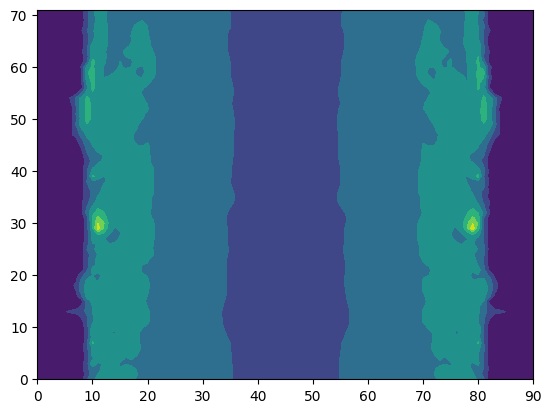

In [12]:
test=torch.permute(torch.tensor(DF_Data[["U","V","urms","vrms","uv"]].to_numpy(),dtype=torch.float32).reshape((int(N_c*N_x/N_x_sub),N_x_sub,N_y,5)),(0,3,1,2))
plt.contourf(test[0,2,:,:])

In [13]:
test.shape

torch.Size([576, 5, 72, 91])

In [14]:
#Data_Pinn=torch.tensor(DF_Data[["U","V","urms","vrms","uv"]].to_numpy().transpose((1,0)).reshape((5,N_c,N_x,N_y)),dtype=torch.float32,device=GPU)
#Data_Pinn=Data_Pinn.transpose(1,0)

In [15]:
Data_Pinn=torch.permute(torch.tensor(DF_Data[["U","V","urms","vrms","uv"]].to_numpy(),dtype=torch.float32,device=GPU).reshape((int(N_c*N_x/N_x_sub),N_x_sub,N_y,5)),(0,3,1,2))

In [16]:
Data_Pinn.shape

torch.Size([576, 5, 72, 91])

 # Calculation of y gird

In [17]:
eta=torch.cos(torch.pi*(torch.tensor([i for i in range(N_y)],requires_grad=False,device=GPU))/(N_y)) 
ys=(1-eta)
ys

tensor([0.0000e+00, 5.9587e-04, 2.3828e-03, 5.3585e-03, 9.5196e-03, 1.4861e-02,
        2.1376e-02, 2.9058e-02, 3.7897e-02, 4.7882e-02, 5.9002e-02, 7.1244e-02,
        8.4592e-02, 9.9031e-02, 1.1454e-01, 1.3111e-01, 1.4872e-01, 1.6733e-01,
        1.8694e-01, 2.0752e-01, 2.2905e-01, 2.5149e-01, 2.7482e-01, 2.9902e-01,
        3.2406e-01, 3.4990e-01, 3.7651e-01, 4.0387e-01, 4.3194e-01, 4.6068e-01,
        4.9007e-01, 5.2006e-01, 5.5063e-01, 5.8173e-01, 6.1333e-01, 6.4540e-01,
        6.7788e-01, 7.1075e-01, 7.4396e-01, 7.7748e-01, 8.1126e-01, 8.4527e-01,
        8.7946e-01, 9.1380e-01, 9.4824e-01, 9.8274e-01, 1.0173e+00, 1.0518e+00,
        1.0862e+00, 1.1205e+00, 1.1547e+00, 1.1887e+00, 1.2225e+00, 1.2560e+00,
        1.2893e+00, 1.3221e+00, 1.3546e+00, 1.3867e+00, 1.4183e+00, 1.4494e+00,
        1.4799e+00, 1.5099e+00, 1.5393e+00, 1.5681e+00, 1.5961e+00, 1.6235e+00,
        1.6501e+00, 1.6759e+00, 1.7010e+00, 1.7252e+00, 1.7485e+00, 1.7710e+00,
        1.7925e+00, 1.8131e+00, 1.8327e+

# interpolating dist to required resolution based on N_x

In [18]:
DF_DIST=pd.read_csv("Data/dist_2289_1Ds.csv",header=None)
x_corr=DF_DIST.iloc[0].to_numpy()
dist=DF_DIST.iloc[1:].to_numpy()
x_corr_new=np.linspace(min(x_corr),max(x_corr),N_x)
dist_new=np.zeros((len(dist),N_x))
for i in range(len(dist)):
    dist_new[i,:]=np.interp(x_corr_new,x_corr,dist[i])
x_corr_new=torch.tensor(x_corr_new,requires_grad=False, dtype=torch.float32,device=GPU)
x_corr=torch.tensor(x_corr,requires_grad=False, dtype=torch.float32,device=GPU)
dist_new=torch.tensor(dist_new,requires_grad=False, dtype=torch.float32,device=GPU)
dist=torch.tensor(dist, requires_grad=False,dtype=torch.float32,device=GPU)

In [19]:
ymesh=ys.reshape((1,1,1,-1)).expand((int(N_c*N_x/N_x_sub),1,N_x_sub,-1))

In [20]:
matrix_mask_Data=(ymesh<dist_new.reshape((int(N_c*N_x/N_x_sub),1,N_x_sub,-1)))|(ymesh>=(2-dist_new.reshape((int(N_c*N_x/N_x_sub),1,N_x_sub,-1))))
matrix_mask_Data=matrix_mask_Data.long()

In [21]:
ymesh.shape

torch.Size([576, 1, 72, 91])

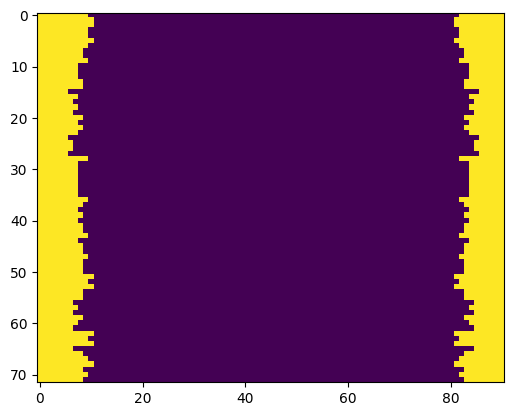

In [22]:
plt.imshow(matrix_mask_Data[1,0,:,:].cpu())

## Define repository of roughness distributions (1d)  
TODO: link repo_dist to togography repository

In [23]:
repo_dist=dist
repo_dist_new=dist_new#
#np.zeros((len(repo_dist),N_x))
#for i in range(len(repo_dist)):
#    repo_dist_new[i,:]=np.interp(x_corr_new,x_corr,repo_dist[i])


# IBM boundary sampler

In [24]:
def IBM_irr_filter_up(x,y,c):
    position_r=torch.tensor([sum(x_corr<x_i)-1 for x_i in x],device=GPU)
    #position_r=sum(x_corr<x)
    position_l=position_r-1
    x_new=torch.transpose(x,1,0)[0]
    c_new=torch.transpose(c,1,0)[0]
    c_new = c_new.to(torch.long)
    height=dist[c_new,position_l]+(dist[c_new,position_r]-dist[c_new,position_l])*(x_new-x_corr[position_l])/(x_corr[position_r]-x_corr[position_l])
    return (y[...,0]>=2-height)   
def IBM_irr_filter_low(x,y,c):
    position_r=torch.tensor([sum(x_corr<x_i)-1 for x_i in x],device=GPU)
    #position_r=sum(x_corr<x)
    position_l=position_r-1
    x_new=torch.transpose(x,1,0)[0]
    c_new=torch.transpose(c,1,0)[0]
    c_new = c_new.to(torch.long)
    height=dist[c_new,position_l]+(dist[c_new,position_r]-dist[c_new,position_l])*(x_new-x_corr[position_l])/(x_corr[position_r]-x_corr[position_l])
    return (y[...,0]<=height)
IBM_sampler_irr_low = tp.samplers.RandomUniformSampler(Sim_domain_sub_low,n_points=1000,filter_fn=IBM_irr_filter_low).make_static(resample_interval=2000)
IBM_sampler_irr_up = tp.samplers.RandomUniformSampler(Sim_domain_sub_up,n_points=1000,filter_fn=IBM_irr_filter_up).make_static(resample_interval=2000)

# Fluid domain sampler

In [25]:
def Inner_filter(x,y,c):
    position_r=torch.tensor([sum(x_corr<x_i)-1 for x_i in x],device=GPU)
    #position_r=sum(x_corr<x)
    position_l=position_r-1
    x_new=torch.transpose(x,1,0)[0]
    c_new=torch.transpose(c,1,0)[0]
    c_new = c_new.to(torch.long)
    height=dist[c_new,position_l]+(dist[c_new,position_r]-dist[c_new,position_l])*(x_new-x_corr[position_l])/(x_corr[position_r]-x_corr[position_l])
    return (y[...,0]>height) &(y[...,0]<2-height)   
inner_sampler = tp.samplers.RandomUniformSampler(Sim_domain, n_points=5000,filter_fn=Inner_filter).make_static(resample_interval=2000)#,filter_fn=Inner_filter)

In [26]:

bound_sampler_low = tp.samplers.RandomUniformSampler(Y_interval.boundary_left*X_interval*C_interval, n_points=250)

bound_sampler_up = tp.samplers.RandomUniformSampler(X_interval*Y_interval.boundary*C_interval, n_points=500)

# PINN model with Fourier feature extraction  & CNN

In [27]:
def self_sin(input):
    return input.sin()
def self_cos(input):
    return input.cos()

In [28]:
import torch.nn as nn
import torch.nn.functional as F
torch.manual_seed(seed=42)
class FCN_model_Fourier_Feature_CNN(nn.Module):
    def __init__(self,input_space,output_space,N_features,sigma_1=1,sigma_2=10):
        super().__init__()
        self.W_1 = torch.tensor(torch.randn(input_space.dim , N_features //2, dtype=torch.float32,device=GPU) * sigma_1, dtype=torch.float32, requires_grad=False)
        self.W_2 = torch.tensor(torch.randn(input_space.dim , N_features //2, dtype=torch.float32,device=GPU) * sigma_2, dtype=torch.float32, requires_grad=False)
        self.register_buffer("selfW1", self.W_1, persistent=False)
        self.register_buffer("selfW2", self.W_2, persistent=False)
        self.output_space=output_space
        self.fc1_l=nn.Linear(in_features=N_features,out_features=150,device=GPU)
        self.fc2_l=nn.Linear(in_features=150,out_features=150,device=GPU)
        self.fc3_l=nn.Linear(in_features=150,out_features=150,device=GPU)
        ###
        self.fc1_r=nn.Linear(in_features=N_features,out_features=150,device=GPU)
        self.fc2_r=nn.Linear(in_features=150,out_features=150,device=GPU)
        self.fc3_r=nn.Linear(in_features=150,out_features=150,device=GPU)


        self.conv1=nn.Conv1d(1,3,3,stride=1,padding=1,device=GPU) #((720-3+2*1)/1)+1 *8=720 *3
        self.act1=nn.LeakyReLU(0.1)
        #self.pool1=nn.MaxPool1d(kernel_size=2) # stride=2   (720-2)/2 + 1 *8 = 360 *3
        
        self.conv2=nn.Conv1d(3,6,3,stride=1,padding=1,device=GPU) # ((720-3+2*1)/1)+1 *32 = 720*6
        self.act2=nn.LeakyReLU(0.1)
        self.pool2=nn.MaxPool1d(kernel_size=2) #360*6

        self.conv3=nn.Conv1d(6,9,5,stride=3,padding=1,device=GPU) #((360-5+2*1)/3)+1 *32 = 120*9
        self.act3=nn.LeakyReLU(0.1)
        self.pool3=nn.MaxPool1d(kernel_size=2)# 60*9
        self.conv4=nn.Conv1d(9,12,5,stride=3,padding=1,device=GPU) #((60-5+2*1)/3)+1 *32 = 20*9
        self.act4=nn.LeakyReLU(0.1)
        self.pool4=nn.MaxPool1d(kernel_size=2)# 10*12
        self.flat=nn.Flatten()
        
        self.fc_combo1=nn.Linear(in_features=120+300,out_features=512,device=GPU)
        self.fc_combo2=nn.Linear(in_features=512,out_features=512,device=GPU)
        
        self.out=nn.Linear(in_features=512,out_features=output_space.dim,device=GPU)
    def forward(self,dist_1d,t):
        t=t.as_tensor[:,0:2]
        t_1=torch.concat((self_sin(torch.matmul(t,self.W_1)),self_cos(torch.matmul(t,self.W_1))),1)
        t_1=self_sin(self.fc1_l(t_1))
        t_1=self_sin(self.fc2_l(t_1))
        t_1=self_sin(self.fc2_l(t_1))
        t_1=self_sin(self.fc3_l(t_1))
        t_2=torch.concat((self_sin(torch.matmul(t,self.W_2)),self_cos(torch.matmul(t,self.W_2))),1)
        t_2=self_sin(self.fc1_r(t_2))
        t_2=self_sin(self.fc2_r(t_2))
        t_2=self_sin(self.fc2_r(t_2))
        t_2=self_sin(self.fc3_r(t_2))
        t_figure=self.act1(self.conv1(dist_1d))
        t_figure=self.pool2(self.act2(self.conv2(t_figure)))
        t_figure=self.pool3(self.act3(self.conv3(t_figure)))
        t_figure=self.pool4(self.act4(self.conv4(t_figure)))
        t=torch.concat((t_1,t_2,self.flat(t_figure)),1)
        t=self_sin(self.fc_combo1(t))
        t=self_sin(self.fc_combo2(t))
        t=self.out(t)
        return tp.problem.spaces.Points(t, self.output_space)
        
model=FCN_model_Fourier_Feature_CNN(input_space=X*Y,output_space=U*V*URMS*VRMS*UV*P,N_features=300)

/tmp/ipykernel_303400/3469751874.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.W_1 = torch.tensor(torch.randn(input_space.dim , N_features //2, dtype=torch.float32,device=GPU) * sigma_1, dtype=torch.float32, requires_grad=False)
/tmp/ipykernel_303400/3469751874.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.W_2 = torch.tensor(torch.randn(input_space.dim , N_features //2, dtype=torch.float32,device=GPU) * sigma_2, dtype=torch.float32, requires_grad=False)


## Disc input cases * (Mast+U+V+urms+vrms+uv)*N_x*N_y output 1/0

In [29]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        # 300 * 100
        self.conv1=nn.Conv2d(6,12,3,stride=1,padding=1,device=GPU) #((30-3+2*1)/1)+1 * ((91-3+2*1)/1)+1 *18 =72 * 91 *18
        self.bn1=nn.BatchNorm2d(12)
        self.act1=nn.ReLU()
        #self.pool1=nn.MaxPool2d(kernel_size=2,stride=2) # stride=2   (300-2)/2 + 1  * (100-2)/2 + 1 *18 =  15 45  *18+

        self.conv2=nn.Conv2d(12,18,3,stride=1,padding=1,device=GPU) #((23-3+2*1)/1)+1 * ((36-3+2*1)/1)+1 *32 =72 * 91 *32
        self.bn2=nn.BatchNorm2d(18)
        self.act2=nn.ReLU()
        #self.pool2=nn.MaxPool2d(kernel_size=2,stride=2) # stride=2   (150-2)/2 + 1  * (50-2)/2 + 1 *18 =  7 * 22  *12

        self.conv3=nn.Conv2d(18,24,5,stride=1,padding=2,device=GPU) #((7-5+2*2)/1)+1 * ((22-5+2*1)/1)+1 *18 =72*91
        self.bn3=nn.BatchNorm2d(24)
        self.act3=nn.ReLU()
        #self.pool3=nn.MaxPool2d(kernel_size=2,stride=2) # stride=2   (21-2)/2 + 1  * (34-2)/2 + 1 *18 =  36*45

        self.conv4=nn.Conv2d(24,30,5,stride=3,padding=2,device=GPU) #((72-5+2*2)/3)+1 * ((91-5+2*2)/3)+1 *64 =23 * 30 *64
        self.bn4=nn.BatchNorm2d(30)
        self.act4=nn.ReLU()
        #self.pool4=nn.MaxPool2d(kernel_size=2,stride=2) # stride=2   (8-2)/2 + 1  * (15-2)/2 + 1 *64 =  18 * 22  *64

        self.conv5=nn.Conv2d(30,36,5,stride=3,padding=2,device=GPU) #((23-5+2*2)/3)+1 * ((30-5+2*2)/3)+1 *64 =7 * 9 *64
        self.bn5=nn.BatchNorm2d(36)
        self.act5=nn.ReLU()
        #self.pool5=nn.MaxPool2d(kernel_size=2,stride=2) # stride=2   (8-2)/2 + 1  * (15-2)/2 + 1 *64 =  9 * 11  *36

        #self.conv6=nn.Conv2d(36,42,5,stride=3,padding=2,device=GPU) #((7-7+2*3)/1)+1 * ((17-5+2*1)/1)+1 *64 =9 * 11 *64
        #self.act6=nn.LeakyReLU(0.1)
        #self.pool6=nn.MaxPool2d(kernel_size=2,stride=2) # stride=2   (8-2)/2 + 1  * (15-2)/2 + 1 *64 =  4 * 5  *42
        
        self.flat=nn.Flatten()

        self.fc_combo1=nn.Linear(in_features=3168,out_features=4096,device=GPU)
        
        self.act_MLP1=nn.LeakyReLU(0.1)
        self.fc_combo2=nn.Linear(in_features=4096,out_features=4096,device=GPU)
        self.act_MLP2=nn.LeakyReLU(0.1)
        self.fc_combo3=nn.Linear(in_features=4096,out_features=2048,device=GPU)
        self.act_MLP3=nn.LeakyReLU(0.1)
        self.fc_combo4=nn.Linear(in_features=2048,out_features=2048,device=GPU)
        self.act_MLP4=nn.LeakyReLU(0.1)
        self.fc_combo5=nn.Linear(in_features=2048,out_features=1,device=GPU)

        self.act_binary=nn.Sigmoid()


    
    def forward(self,x):
        x=self.act1(self.bn1(self.conv1(x)))
        x=self.act2(self.bn2(self.conv2(x)))
        x=self.act3(self.bn3(self.conv3(x)))

        x=self.act4(self.bn4(self.conv4(x)))

        x=self.act5(self.bn5(self.conv5(x)))
       # x=self.act3(self.conv3(x))
        #x=self.pool4(self.act4(self.conv4(x)))
        x=self.act_MLP1(self.fc_combo1(self.flat(x)))
        x=self.act_MLP2(self.fc_combo2(x))
        x=self.act_MLP3(self.fc_combo3(self.flat(x)))
        x=self.act_MLP4(self.fc_combo4(x))
        x=self.act_binary(self.fc_combo5(x))
        return x


disc=Discriminator()

In [30]:
print(disc)

Discriminator(
  (conv1): Conv2d(6, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(12, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act1): LeakyReLU(negative_slope=0.1)
  (conv2): Conv2d(12, 18, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(18, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act2): LeakyReLU(negative_slope=0.1)
  (conv3): Conv2d(18, 24, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (bn3): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act3): LeakyReLU(negative_slope=0.1)
  (conv4): Conv2d(24, 30, kernel_size=(5, 5), stride=(3, 3), padding=(2, 2))
  (bn4): BatchNorm2d(30, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act4): LeakyReLU(negative_slope=0.1)
  (conv5): Conv2d(30, 36, kernel_size=(5, 5), stride=(3, 3), padding=(2, 2))
  (bn5): BatchNorm2d(36, eps=1e-05, momentum=0.1, affine=True, track_running_stats=Tr

In [31]:
def pde_IBM(u,v):
    return torch.sqrt(torch.square(u)+torch.square(v))
pde_cond_IBM_up = tp.conditions.PINNCondition_CNN(model, IBM_sampler_irr_up, pde_IBM, dist_matrix=dist,weight=10,name='IBM_up')
pde_cond_IBM_low = tp.conditions.PINNCondition_CNN(model, IBM_sampler_irr_low, pde_IBM, dist_matrix=dist,weight=10,name='IBM_low')

In [32]:
def pde_IBM_uu(urms,vrms,uv,p):
    return torch.abs(urms)+torch.abs(vrms)+torch.abs(uv)+torch.abs(p)
pde_cond_IBM_up_uu = tp.conditions.PINNCondition_CNN(model, IBM_sampler_irr_up, pde_IBM_uu, dist_matrix=dist,weight=10,name='IBM_up_uu')
pde_cond_IBM_low_uu = tp.conditions.PINNCondition_CNN(model, IBM_sampler_irr_low, pde_IBM_uu, dist_matrix=dist,weight=10,name='IBM_low_uu')

In [33]:
def pde_mass(u,v,x,y):
    return tp.utils.grad(u,x)+tp.utils.grad(v,y)-0.0
pde_cond_mass = tp.conditions.PINNCondition_CNN(model, inner_sampler,pde_mass, dist_matrix=dist, weight=50,name='Conti')

In [34]:
def pde_residual_x(u,v, x, y,urms,vrms,uv,p,c):
    c_new=torch.transpose(c,1,0)[0]
    c_new = c_new.to(torch.long)
    residual_momentum= u*tp.utils.grad(u,x)+ v*tp.utils.grad(u,y)+(-tp.utils.laplacian(u, x)-tp.utils.laplacian(u,y))/6000 - ( (2/15)**2/((1-torch.mean(dist[c_new,:]))**3) ) +tp.utils.grad(torch.square(urms/6),x)+tp.utils.grad(uv/60,y)+tp.utils.grad(p,x)
    return residual_momentum

pde_cond_x = tp.conditions.PINNCondition_CNN(model, inner_sampler, pde_residual_x, dist_matrix=dist,weight=51,name='Momentum_x')

In [35]:
def pde_residual_y(u,v, x, y,urms,vrms,uv,p):
    residual_momentum= u*tp.utils.grad(v,x)+v*tp.utils.grad(v,y)+(-tp.utils.laplacian(v, x)-tp.utils.laplacian(v,y))/6000+tp.utils.grad(uv/60,x)+tp.utils.grad(torch.square(vrms/6),y)+tp.utils.grad(p,y)
    return residual_momentum

pde_cond_y = tp.conditions.PINNCondition_CNN(model, inner_sampler, pde_residual_y, dist_matrix=dist,weight=50,name='Momentum_y')

In [36]:
def boundary_residual_x(u, x,y):
    return torch.square(u) - 0.0

boundary_cond_x = tp.conditions.PINNCondition_CNN(model, bound_sampler_up, boundary_residual_x, dist_matrix=dist, weight=1,name='noslip_x')

In [37]:
def boundary_residual_y(v, x,y):
    return torch.square(v) - 0.0

boundary_cond_y = tp.conditions.PINNCondition_CNN(model, bound_sampler_up, boundary_residual_y, dist_matrix=dist, weight=1,name='noslip_y')

In [38]:
def boundary_residual_uu(urms, x,y):
    return torch.square(urms) - 0.0

boundary_cond_uu = tp.conditions.PINNCondition_CNN(model, bound_sampler_up, boundary_residual_uu, dist_matrix=dist, weight=1,name='noslip_x_uu')

In [39]:
def boundary_residual_vv(vrms, x,y):
    return torch.square(vrms) - 0.0

boundary_cond_vv = tp.conditions.PINNCondition_CNN(model, bound_sampler_up, boundary_residual_vv, dist_matrix=dist, weight=1,name='noslip_x_vv')

In [40]:
def boundary_residual_uv(uv, x,y):
    return uv - 0.0

boundary_cond_uv = tp.conditions.PINNCondition_CNN(model, bound_sampler_up, boundary_residual_uv, dist_matrix=dist, weight=1,name='noslip_x_uv')

In [41]:

Periodic_sampler=tp.samplers.RandomUniformSampler(Y_interval*C_interval,n_points=250).make_static(resample_interval=2000)#,filter_fn=Inner_filter)

In [42]:
def periodic_residual_x(u_left,u_right):
    Periodic_condition= u_left - u_right
    return Periodic_condition
periodic_cond_x=tp.conditions.PeriodicCondition_CNN(model,X_interval,periodic_residual_x,dist_matrix=dist,non_periodic_sampler=Periodic_sampler, weight=1,name='periodic_x')

In [43]:
def periodic_residual_y(v_left,v_right):
    Periodic_condition= v_left - v_right
    return Periodic_condition
periodic_cond_y=tp.conditions.PeriodicCondition_CNN(model,X_interval,periodic_residual_y,dist_matrix=dist,non_periodic_sampler=Periodic_sampler, weight=1,name='periodic_y')

In [44]:
def periodic_residual_uu(urms_left,urms_right):
    Periodic_condition= urms_left - urms_right
    return Periodic_condition
periodic_cond_uu=tp.conditions.PeriodicCondition_CNN(model,X_interval,periodic_residual_uu,dist_matrix=dist,non_periodic_sampler=Periodic_sampler, weight=1,name='periodic_uu')

In [45]:
def periodic_residual_vv(vrms_left,vrms_right):
    Periodic_condition= vrms_left - vrms_right
    return Periodic_condition
periodic_cond_vv=tp.conditions.PeriodicCondition_CNN(model,X_interval,periodic_residual_vv,dist_matrix=dist,non_periodic_sampler=Periodic_sampler, weight=1,name='periodic_vv')

In [46]:
def periodic_residual_uv(uv_left,uv_right):
    Periodic_condition= uv_left - uv_right
    return Periodic_condition
periodic_cond_uv=tp.conditions.PeriodicCondition_CNN(model,X_interval,periodic_residual_uv,dist_matrix=dist,non_periodic_sampler=Periodic_sampler, weight=1,name='periodic_uv')

In [47]:
def periodic_residual_p(p_left,p_right):
    Periodic_condition= p_left-p_right
    return Periodic_condition
periodic_cond_p=tp.conditions.PeriodicCondition(model,X_interval,periodic_residual_p,non_periodic_sampler=Periodic_sampler, weight=1,name='periodic_p')

In [48]:
bound_sampler_left = tp.samplers.RandomUniformSampler(X_interval.boundary_left*Y_interval, n_points=250)
def boundary_residual_p(p, x,y):
    return p

periodic_cond_p=tp.conditions.PeriodicCondition_CNN(model,X_interval,periodic_residual_p,dist_matrix=dist,non_periodic_sampler=Periodic_sampler, weight=1,name='periodic_p')

In [49]:
bound_sampler_left = tp.samplers.RandomUniformSampler(X_interval.boundary_left*Y_interval*C_interval, n_points=250)
def boundary_residual_p(p, x,y):
    return p

boundary_cond_p = tp.conditions.PINNCondition_CNN(model, bound_sampler_left, boundary_residual_p, dist_matrix=dist, weight=1,name='bound_p')

In [50]:
##Learning rate scheduling To-Do -- launch LR scheduling only after first training phase
optim_G = tp.OptimizerSetting(torch.optim.Adam, lr=0.0001,scheduler_class=torch.optim.lr_scheduler.ReduceLROnPlateau,scheduler_args={"patience":20000,"factor":0.8,"verbose":True,"min_lr":0.000005},monitor_lr="train/model_loss")
optim_D = tp.OptimizerSetting(torch.optim.Adam, lr=0.0001,scheduler_class=torch.optim.lr_scheduler.ReduceLROnPlateau,scheduler_args={"patience":20000,"factor":0.8,"verbose":True,"min_lr":0.000005},monitor_lr="train/D_loss")
#solver = tp.solver.Solver([pde_cond_IBM,pde_cond_mass,boundary_cond_x, pde_cond_x,periodic_cond_x,boundary_cond_y, pde_cond_y,periodic_cond_y], optimizer_setting=optim)
##loss terms scheduling
list_of_Losses=[pde_cond_IBM_up,#1000
                           pde_cond_IBM_low,
                           pde_cond_IBM_up_uu,#1000
                           pde_cond_IBM_low_uu,
                           boundary_cond_x,#1000
                           boundary_cond_y,
                           boundary_cond_uu,#1000
                           boundary_cond_vv,
                           boundary_cond_uv,
                           boundary_cond_p,
                           periodic_cond_x,#2000
                           periodic_cond_y,
                           periodic_cond_uu,#2000
                           periodic_cond_vv,
                           periodic_cond_uv,
                           periodic_cond_p,
                           pde_cond_x,#5000
                           pde_cond_y,#5000
                           pde_cond_mass]
solver = tp.solver.PIAN_Solver_CNN_Wasserstein_LowMem(list_of_Losses,#1000
                               generator=model,
                               discriminator=disc,
                          optimizer_setting_G=optim_G,
                        optimizer_setting_D=optim_D,
                         loss_function_schedule=[     
                             {
                        "conditions":list(range(len(list_of_Losses))),
                        "max_iter":200000
                    }
                ],
                          weight_tunning=True,
                          weight_tunning_parameters={
                                    "alfa":0.99,
                                    "E_rho":0.99,
                                    "Temperature":0.1,
                                    "tunning_every_n_steps":100
                          }, ## Default weight-tunning settings
                                GAN_weight=GAN_weight,
                               co_sys=X*Y,
                                   disc_space=U*V*URMS*VRMS*UV,
                                   N_dist=N_dists,## number of 1d roughness -> N 2d flow fileds
                                   L_x=L_x,
                                   N_x=N_x,
                                   N_y=N_y,
                                   dist_repository=repo_dist[:,None,:],
                                   dist_repository_low=dist_new[:,None,:],
                                   gpu=GPU,
                                N_x_sub=N_x_sub,
                         )

/usr/local/lib/python3.10/dist-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3190.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
/usr/local/lib/python3.10/dist-packages/torchphysics/solver.py:1925: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.coords = torch.tensor(torch.concat((meshx,meshy),axis=1).expand((self.N_dist,self.N_x_sub*self.N_y,2)).reshape((self.N_x_sub*self.N_y*self.N_dist,2)),dtype=torch.float32,device=gpu)


In [51]:
Data_Pinn.shape

torch.Size([576, 5, 72, 91])

In [52]:
matrix_mask_Data.shape

torch.Size([576, 1, 72, 91])

In [53]:
class Data_set_pinn(torch.utils.data.Dataset):
    def __init__(self,Data_Pinn,matrix_mask_Data):
        #self.x_train=data_DF[x_list].values
        #self.Data_Pinn=DF.to_numpy().reshape((1,-1))
        #self.y_train=data_DF[y_list].values
        self.Data_Pinn=torch.cat((Data_Pinn,matrix_mask_Data),1)
        #self.y_train=torch.tensor(y_train,dtype=torch.float32)
        #self.x_train=tp.spaces.Points(self.x_train,X*Y)
        #self.y_train=tp.spaces.Points(self.y_train,U*V)
    def __len__(self):
        return Data_Pinn.shape[0]

    def __getitem__(self,idx):
        #return self.x_train[idx] , self.y_train[idx]
        #print(torch.as_tensor([self.x_train[idx]]).shape)
        P_xtrain=self.Data_Pinn[idx]
        P_ytrain=self.Data_Pinn[idx]
        return P_xtrain,P_ytrain
dataset_turbulent=Data_set_pinn(Data_Pinn,matrix_mask_Data)

In [54]:
Disc_dataloader=DataLoader(dataset_turbulent,batch_size=N_dists,shuffle=True,drop_last =True)

In [55]:
a,_=next(iter(Disc_dataloader))
a.shape

torch.Size([10, 6, 72, 91])

In [56]:
torch.set_float32_matmul_precision('medium')
comet_logger = pl_loggers.CSVLogger(save_dir="logs/")
trainer = pl.Trainer(gpus=1,# use one GPU
                     max_steps=500000, # iteration number
                     benchmark=True, # faster if input batch has constant size
                     logger=comet_logger, # for writting into tensorboard
                     log_every_n_steps=100,
                     enable_checkpointing=False,
                     limit_val_batches=0,
                        num_sanity_val_steps=0) # saving checkpoints ToDo: turn on checkpointing after first training phase
trainer.fit(solver,train_dataloaders=Disc_dataloader)

/usr/local/lib/python3.10/dist-packages/pytorch_lightning/trainer/connectors/accelerator_connector.py:478: LightningDeprecationWarning: Setting `Trainer(gpus=1)` is deprecated in v1.7 and will be removed in v2.0. Please use `Trainer(accelerator='gpu', devices=1)` instead.
  rank_zero_deprecation(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.10/dist-packages/pytorch_lightning/core/optimizer.py:273: RuntimeWarning: Found unsupported keys in the lr scheduler dict: {'patience', 'verbose', 'min_lr', 'factor'}. HINT: remove them from the output of `configure_optimizers`.
  rank_zero_warn(

  | Name             | Type                          | Params
-------------------------------------------------------------------
0 | generator        | FCN_model_Fourier_Feature_CNN | 663 K 
1 | discriminator    | Discriminator         

Epoch 41:  74%|██████████████████████████████████████▎             | 42/57 [09:01<03:13, 12.90s/it, loss=8.5, v_num=205]

/usr/local/lib/python3.10/dist-packages/pytorch_lightning/trainer/call.py:48: UserWarning: Detected KeyboardInterrupt, attempting graceful shutdown...
  rank_zero_warn("Detected KeyboardInterrupt, attempting graceful shutdown...")


In [57]:
6*144*91*5


393120

In [58]:
torch.save(model,"Flat_PIAN_CNN_OPT_Wasserstein.pt")

In [59]:
a,_=next(iter(Disc_dataloader))
disc(a)

tensor([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.]], device='cuda:0', grad_fn=<SigmoidBackward0>)

In [60]:
dist_new.shape

torch.Size([288, 144])

In [61]:
disc(solver(dist[0].expand((10,1,dist.shape[1])),dist_new[0].expand((10,1,dist_new.shape[1])),torch.tensor([1]).expand(10,1)))

tensor([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.]], device='cuda:0', grad_fn=<SigmoidBackward0>)

In [62]:
def produce_sample(x_max,y_max,c,other_Constrains,resolution=100):
    list_x=np.linspace(0,x_max,resolution)
    list_y=np.linspace(0,y_max,resolution)
    XM,YM=np.meshgrid(list_x,list_y)
    model_value_x=np.zeros(XM.shape)
    model_value_y=np.zeros(XM.shape)    
    model_value_urms=np.zeros(XM.shape)
    model_value_uv=np.zeros(XM.shape)
    model_value_p=np.zeros(XM.shape)
    dist_1d=dist[c][None,None,:]
    for i in range(len(list_x)):
        for j in range(len(list_y)):
            coords = torch.tensor([[list_x[i],list_y[j],c]], dtype=torch.float32,device=GPU)
            model_value_x[i,j] = model(dist_1d,tp.spaces.Points(coords, X*Y*C)).as_tensor[0,0]
            model_value_y[i,j] = model(dist_1d,tp.spaces.Points(coords, X*Y*C)).as_tensor[0,1]
            model_value_urms[i,j] = model(dist_1d,tp.spaces.Points(coords, X*Y*C)).as_tensor[0,2]
            model_value_uv[i,j] = model(dist_1d,tp.spaces.Points(coords, X*Y*C)).as_tensor[0,4]
            model_value_p[i,j] = model(dist_1d,tp.spaces.Points(coords, X*Y*C)).as_tensor[0,5]
    model_value_urms=np.transpose(model_value_urms)
    model_value_uv=np.transpose(model_value_uv)
    model_value_x=np.transpose(model_value_x)
    model_value_y=np.transpose(model_value_y)
    model_value_p=np.transpose(model_value_p)
    plt.contourf(model_value_urms,levels=10,extent=[0, x_max, 0, y_max],origin='lower')    
    plt.colorbar()
    plt.plot(x_corr.cpu(),dist[c].cpu())
    return model_value_x

Text(0.5, 1.0, 'predicted')

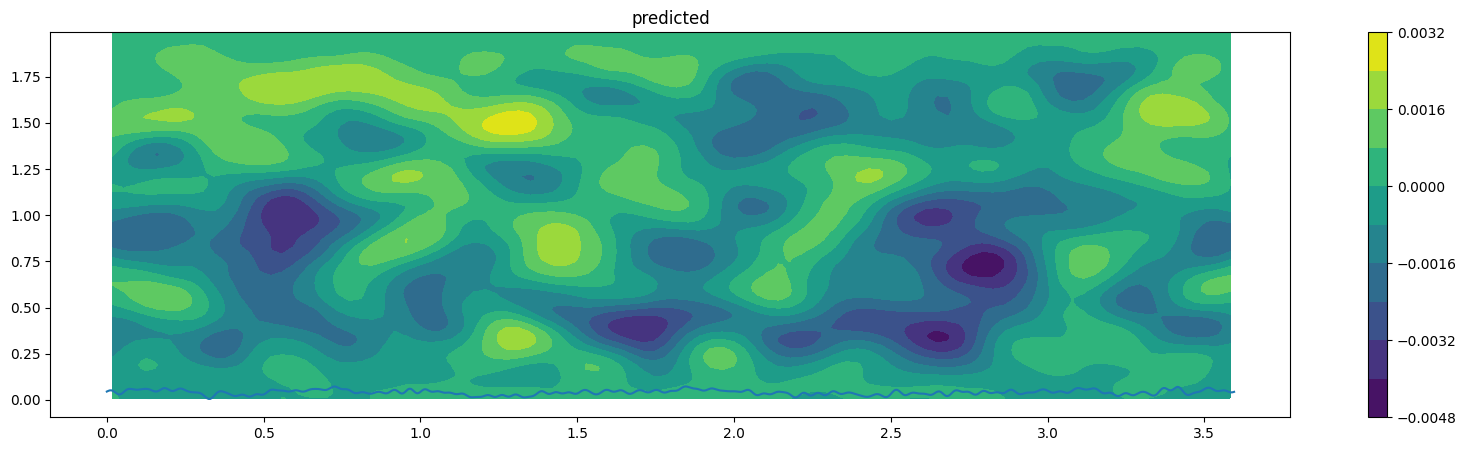

In [63]:
plt.figure(figsize=(20,5))

model_values=produce_sample(3.6,2,0,200)
plt.title("predicted")

In [64]:
dist_1d=dist[0][None,None,:]
dist_1d=dist_1d.expand(8,-1,-1)
coords = torch.tensor([[0,0,0],[0,0,0],[0,0,0],[0,0,0],[0,0,0],[0,0,0],[0,0,0],[0,0,0]], dtype=torch.float32)
prediction=model(dist_1d,tp.spaces.Points(coords, X*Y*C)).as_tensor[:,0:5]
prediction

RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cpu and cuda:0! (when checking argument for argument mat2 in method wrapper_mm)

In [ ]:
torch.permute(prediction.reshape((1,4,2,5)),(0,3,1,2))

In [ ]:
dist_sub=dist[[0,1,2],:]
dist_sub=dist_sub[:,None,:]

In [ ]:
dist[[0,1,2],:]

In [ ]:
dist_input=dist_sub.expand(2*2,3,1,dist_sub.shape[2]).transpose(1,0).reshape((-1,1,dist_sub.shape[2]))

In [ ]:
dist_input

In [ ]:
model_values=produce_sample(2,2,100)


In [ ]:
for j in np.linspace(0,2,10):
    coords = torch.tensor([[j,i] for i in np.linspace(0,2,100)], dtype=torch.float32)
    model_out = model(tp.spaces.Points(coords, X*Y)).as_tensor
    for k in range(2,5):
        plt.plot(np.linspace(0,2,100),np.array(model_out.transpose(0,1)[k].tolist()))
    #plt.plot([0.4,0.4],[0.1,-0.1])

In [ ]:
coords = torch.tensor([[0,i] for i in np.linspace(0,2,100)], dtype=torch.float32)
model_out = model(tp.spaces.Points(coords, X*Y)).as_tensor
for k in range(2,5):
    plt.plot(np.linspace(0,2,100),np.array(model_out.transpose(0,1)[k].tolist()))
    #plt.plot([0.4,0.4],[0.1,-0.1])

In [ ]:
coords = torch.tensor([[1,i] for i in DF_Data["y"]], dtype=torch.float32)
model_out = model(tp.spaces.Points(coords, X*Y)).as_tensor
for k in range(2,4):
    plt.plot(DF_Data["y"],(np.array(model_out.transpose(0,1)[k].tolist())/6))
    #plt.plot([0.4,0.4],[0.1,-0.1])
plt.plot(DF_Data["y"],(np.array(model_out.transpose(0,1)[4].tolist())/60))
plt.plot(DF_Data["y"],DF_Data["urms"],'--')
plt.plot(DF_Data["y"],DF_Data["vrms"],'--')
plt.plot(DF_Data["y"],DF_Data["uv"],'--')
plt.scatter(ys,DF["urms"]/6,s=15)
plt.title("Reynolds stresses")
plt.savefig("stress.png")

In [ ]:
coords = torch.tensor([[1.8,i] for i in DF_Data["y"]], dtype=torch.float32)
model_out = model(tp.spaces.Points(coords, X*Y)).as_tensor
for k in range(0,2):
    plt.plot(DF_Data["y"],np.array(model_out.transpose(0,1)[k].tolist()))
    #plt.plot([0.4,0.4],[0.1,-0.1])
plt.plot(DF_Data["y"],DF_Data["U"],'--')
plt.plot(DF_Data["y"],DF_Data["V"],'--')
plt.scatter(ys,DF["U"],s=15)
plt.xscale("log")
plt.title("Mean profiles")
plt.savefig("mean.png")

In [ ]:
DF_Data

In [ ]:
for j in np.linspace(0,2,10):
    coords = torch.tensor([[j,i,20] for i in np.linspace(0,2,100)], dtype=torch.float32)
    model_out = model(tp.spaces.Points(coords, X*Y*H)).as_tensor
    plt.plot(np.linspace(0,2,100),np.array(model_out.transpose(0,1)[0].tolist()))
    plt.plot([0.3,0.3],[0.1,-0.1])

In [ ]:
coords = torch.tensor([[5,i] for i in np.linspace(0,2.0,100)], dtype=torch.float32)
model_out = model(tp.spaces.Points(coords, X*Y)).as_tensor
plt.plot(np.array(model_out.transpose(0,1)[0].tolist()))
coords = torch.tensor([[0,i] for i in np.linspace(0,2.0,100)], dtype=torch.float32)
model_out = model(tp.spaces.Points(coords, X*Y)).as_tensor
plt.plot(np.array(model_out.transpose(0,1)[0].tolist()))